In [1]:
# Set up logging to display in Jupyter Notebook
import logging

logging.basicConfig(
    level=logging.ERROR,  # Show ERROR and above
    format="%(levelname)s: %(message)s",  # Format: "ERROR: message"
    force=True,  # Needed in Jupyter to reset config
)

In [2]:
!mkdir -p figures

In [3]:
import numpy as np
import cvxpy as cp
from scipy.spatial.distance import jensenshannon

In [4]:
import sys
sys.path.append("../")

In [ ]:
from flow.solve_mix import *
from flow.interface import *
from utils.handy_states import *

In [6]:
def balance_obj_problem(
    problem_spec: ProblemSpec,
    ideal_distrib,
    param_a,
    prior_prob: list[float] | None = None,
) -> cp.Problem:
    assert problem_spec.state_type == "densitymatrix"
    logger = logging.getLogger(__name__)

    k = problem_spec.num_states

    # PI is the variable for the POVM elements we try to solve for.
    PI_list = [
        cp.Variable(
            shape=(problem_spec.num_amps, problem_spec.num_amps),
            hermitian=True,
            name=f"PI_{i}",
        )
        for i in range(k + 1)
    ]

    # https://www.cvxpy.org/tutorial/dpp/index.html
    # DPP forbids taking the product of two parametrized expressions,
    # so we will not parametrize prior probabilities.
    # Actually for this formulation, it is fine to parametrize it.
    # For code uniformity, we will not do it.
    # prior_prob = cp.Parameter(k, name="prior_prob")
    if prior_prob is None:
        prior_prob = np.ones(k) * (1 / k)
        logger.info(f"The prior probabilities is set to uniform (k = {k})")
    else:
        logger.info(f"The prior probabilities is set to {prior_prob}")

    prob_succ_expr = get_prob_succ_expr(
        problem_spec=problem_spec, prior_prob=prior_prob, PI_list=PI_list
    )

    l1_expr = get_l1_dist_expr(
        problem_spec=problem_spec,
        prior_prob=prior_prob,
        PI_list=PI_list,
        prob_mat=ideal_distrib,
    )

    obj_expr = prob_succ_expr - param_a * l1_expr

    objective = cp.Maximize(obj_expr)
    constraints = []

    # Constraint 1. Positive operators
    for i in range(k + 1):
        constraints.append(PI_list[i] >> 0)

    # Constraint 2. Completeness
    I = np.identity(problem_spec.num_amps)
    constraints.append(cp.sum(PI_list) == I)

    return cp.Problem(objective, constraints)

In [7]:
def balance_obj_2_problem(
    problem_spec: ProblemSpec,
    ideal_distrib,
    param_b,
    param_rh,
    param_rv,
    prior_prob: list[float] | None = None,
) -> cp.Problem:
    assert problem_spec.state_type == "densitymatrix"
    logger = logging.getLogger(__name__)

    k = problem_spec.num_states

    # PI is the variable for the POVM elements we try to solve for.
    PI_list = [
        cp.Variable(
            shape=(problem_spec.num_amps, problem_spec.num_amps),
            hermitian=True,
            name=f"PI_{i}",
        )
        for i in range(k + 1)
    ]

    # https://www.cvxpy.org/tutorial/dpp/index.html
    # DPP forbids taking the product of two parametrized expressions,
    # so we will not parametrize prior probabilities.
    # Actually for this formulation, it is fine to parametrize it.
    # For code uniformity, we will not do it.
    # prior_prob = cp.Parameter(k, name="prior_prob")
    if prior_prob is None:
        prior_prob = np.ones(k) * (1 / k)
        logger.info(f"The prior probabilities is set to uniform (k = {k})")
    else:
        logger.info(f"The prior probabilities is set to {prior_prob}")

    prob_succ_expr = get_prob_succ_expr(
        problem_spec=problem_spec, prior_prob=prior_prob, PI_list=PI_list
    )

    l1_expr = get_l1_dist_expr(
        problem_spec=problem_spec,
        prior_prob=prior_prob,
        PI_list=PI_list,
        prob_mat=ideal_distrib,
    )

    # TODO max(rv, rh)
    max_expr = 0

    # Constraint 2. Conditional probability with respect to the measurement operator
    # prior_prob[i] is divided on both sides
    for i in range(k):
        expr_lhs = prior_prob[i] * cp.trace(
            cp.matmul(problem_spec.states[i].data, PI_list[i])
        )
        expr_rhs = cp.sum(
            [
                prior_prob[i]
                * cp.trace(cp.matmul(problem_spec.states[i].data, PI_list[j]))
                for j in range(k)
            ]
        )
        max_expr = cp.minimum(
            max_expr, cp.real(expr_lhs) - cp.real(expr_rhs) * (1 - param_rh[i])
        )

    # Constraint 3. Conditional probability with respect to the input state
    for i in range(k):
        expr_lhs = prior_prob[i] * cp.trace(
            cp.matmul(problem_spec.states[i].data, PI_list[i])
        )
        expr_rhs = cp.sum(
            [
                prior_prob[j]
                * cp.trace(cp.matmul(problem_spec.states[j].data, PI_list[i]))
                for j in range(k)
            ]
        )
        max_expr = cp.minimum(
            max_expr, cp.real(expr_lhs) - cp.real(expr_rhs) * (1 - param_rv[i])
        )

    obj_expr = prob_succ_expr + param_b * max_expr

    objective = cp.Maximize(obj_expr)
    constraints = []

    # Constraint 1. Positive operators
    for i in range(k + 1):
        constraints.append(PI_list[i] >> 0)

    # Constraint 2. Completeness
    I = np.identity(problem_spec.num_amps)
    constraints.append(cp.sum(PI_list) == I)

    return cp.Problem(objective, constraints)

## Define the input states

In [8]:
state_dict = sv_simple_2(0.2, 0.5, 0.7)
num_qubits = state_dict["num_qubits"]
num_states = state_dict["num_states"]
state_vec = state_dict["states"]
dense_mat = [DensityMatrix(_) for _ in state_vec]

In [9]:
#'''
num_qubits = 1
num_states = 2

state_vec = [
    Statevector([1, 0]),
    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),
]
dense_mat = [DensityMatrix(_) for _ in state_vec]
#'''


In [10]:
qsd_problem = ProblemSpec(
    num_qubits=num_qubits,
    num_states=num_states,
    case_id="0813_test",
    state_type="densitymatrix",
)

In [11]:
n = qsd_problem.num_states
# Comment/uncomment to switch between different prior probabilities
prior_prob = np.ones(n) * (1 / n)
# prior_prob = [1/9, 3/9, 5/9]
qsd_problem.prior_prob = prior_prob

In [12]:
qsd_problem.set_states(
    state_type="statevector",
    states=state_vec,
    overwrite=True,
)
ideal_result = apply_Eldar(
    problem_spec=qsd_problem,
    prior_prob=prior_prob,
    cvxpy_settings={
        "solver": cp.MOSEK,
        "verbose": False,
        "eps": 1e-8,
    }
)

ideal_distrib = calculate_prob_matrix_simple(
    prior_probs=prior_prob,
    povm=ideal_result["povm"],
    states=dense_mat,
)
uqsd_opt_val = ideal_result["p_succ"]
print(ideal_result["p_succ"])

0.2928932185164271


/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18617: UserWarning: Argument sub in putvarboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putvarboundlist: Incorrect array format causing data to be copied");
/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18925: UserWarning: Argument subj in putclist: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putclist: Incorrect array format causing data to be copied");
/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18349: UserWarning: Argument sub in putconboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putconboundlist: Incorrect array format causing data to be copied");


In [13]:
cvxpy_settings = {"solver": cp.MOSEK, "verbose": False, "eps": 1e-8}
qsd_problem.set_states(
    state_type="densitymatrix",
    states=dense_mat,
    overwrite=True,
)
cvxpy_med_problem = med_problem(problem_spec=qsd_problem, prior_prob=prior_prob)
cvxpy_med_problem.solve(**cvxpy_settings)
med_opt_val = cvxpy_med_problem.solution.opt_val
print(med_opt_val)

0.8535533902290244


In [14]:
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(11)]
disturbance_states = [
    DensityMatrix(
        ProblemSpec.depolarizing_noise_channel(num_qubits=num_qubits)
    )
    for _ in range(num_states)
]

In [15]:
def get_sqrt_dist(a, b):
    return np.sqrt(sum([abs(a[i] - b[i]) ** 2 for i in range(len(a))]))


def run_qsd(
    qsd_problem: ProblemSpec,
    cvxpy_problem,
    jsd_result,
    sqrtd_result,
    psucc_result,
    eps=1e-8,
):
    cvxpy_settings = {"solver": cp.MOSEK, "verbose": False, "eps": eps}
    cvxpy_problem.solve(**cvxpy_settings)

    # print(cvxpy_problem.status)
    # print(cvxpy_problem.solution.opt_val)
    vars = cvxpy_problem.variables()

    fitqd_povm = [var.value for var in vars]
    # print(fitqd_povm)

    prob_mat = calculate_prob_matrix_simple(
        prior_probs=prior_prob,
        povm=fitqd_povm,
        states=qsd_problem.states,
    )
    # print(prob_mat)

    psucc = 0
    for i in range(qsd_problem.num_states):
        psucc += prob_mat[i][i]
    psucc_result.append(psucc)

    js_dist = jensenshannon(
        np.array(ideal_distrib).flatten(),
        np.array(prob_mat).flatten(),
    )
    jsd_result.append(js_dist)

    sqrt_dist = get_sqrt_dist(
        np.array(ideal_distrib).flatten(),
        np.array(prob_mat).flatten(),
    )
    sqrtd_result.append(sqrt_dist)
    #
    # print("alpha", np.array(calculate_errors(prob_mat)[0]))
    # print("beta ", max(calculate_errors(prob_mat)[1]))
    #
    # print()

In [16]:
med_distrib = calculate_prob_matrix_simple(
    prior_probs=prior_prob,
    povm=[cvxpy_med_problem.variables()[i].value for i in range(len(cvxpy_med_problem.variables()))] + [np.zeros(shape=(qsd_problem.num_amps, qsd_problem.num_amps))],
    states=dense_mat,
)
med_l2 = sqrt_dist = get_sqrt_dist(
    np.array(med_distrib).flatten(),
    np.array(ideal_distrib).flatten(),
)

In [17]:
jsd_result = []
sqrtd_result = []
psucc_result = []
eps_list = [1e-8]
lamdah_list = [0, 0.0001, 0.001, 0.01, 0.1, 1]
lamdah_list = [0.1 * _ for _ in range(10)]
lamdah_list = [0.3 + 0.02 * _ for _ in range(11)]
lamdah_list = [0.2 + 0.04 * _ for _ in range(11)]
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(11)]
noise_levels = [0.1 ** (6 - 0.25 * i) for i in range(25)]
psucc_result_list = []
sqrtd_result_list = []

for param_a in lamdah_list:
    for eps in eps_list:
        jsd_result = []
        sqrtd_result = []
        psucc_result = []
        for noise_level in noise_levels:
            combined_states = [
                (1 - noise_level) * dense_mat[_]
                + noise_level * disturbance_states[_].data
                for _ in range(num_states)
            ]

            qsd_problem.set_states(
                state_type="densitymatrix",
                states=combined_states,
                overwrite=True,
            )

            cvxpy_problem = balance_obj_problem(
                problem_spec=qsd_problem,
                ideal_distrib=ideal_distrib,
                param_a=param_a,
            )

            run_qsd(
                qsd_problem=qsd_problem,
                cvxpy_problem=cvxpy_problem,
                jsd_result=jsd_result,
                sqrtd_result=sqrtd_result,
                psucc_result=psucc_result,
            )
        psucc_result_list.append(psucc_result)
        sqrtd_result_list.append(sqrtd_result)

In [36]:
# OptUQSD under noise
for noise_level in noise_levels:
    combined_states = [
        (1 - noise_level) * dense_mat[_]
        + noise_level * disturbance_states[_].data
        for _ in range(qsd_problem.num_states)
    ]
    # print(combined_states)
    prob_mat = calculate_prob_matrix_simple(
        prior_probs=prior_prob,
        povm=ideal_result["povm"],
        states=combined_states,
    )
    psucc = 0
    for i in range(qsd_problem.num_states):
        psucc += prob_mat[i][i]
    # for i in prob_mat:
    #     print(i)
    # print()
    #print(psucc)
    

In [37]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 16,        # base size for everything
    "axes.labelsize": 18,   # x/y labels
    "axes.titlesize": 20,   # (if you use titles)
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,

    # make curves/markers visually match the larger fonts
    "lines.linewidth": 2.2,
    # "lines.markersize": 5.5,
    "lines.markersize": 7,
})

/tmp/ipykernel_3712620/476584697.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rainbow = cm.get_cmap('rainbow', len(sqrtd_result_list))  # Get 5 colors from rainbow colormap


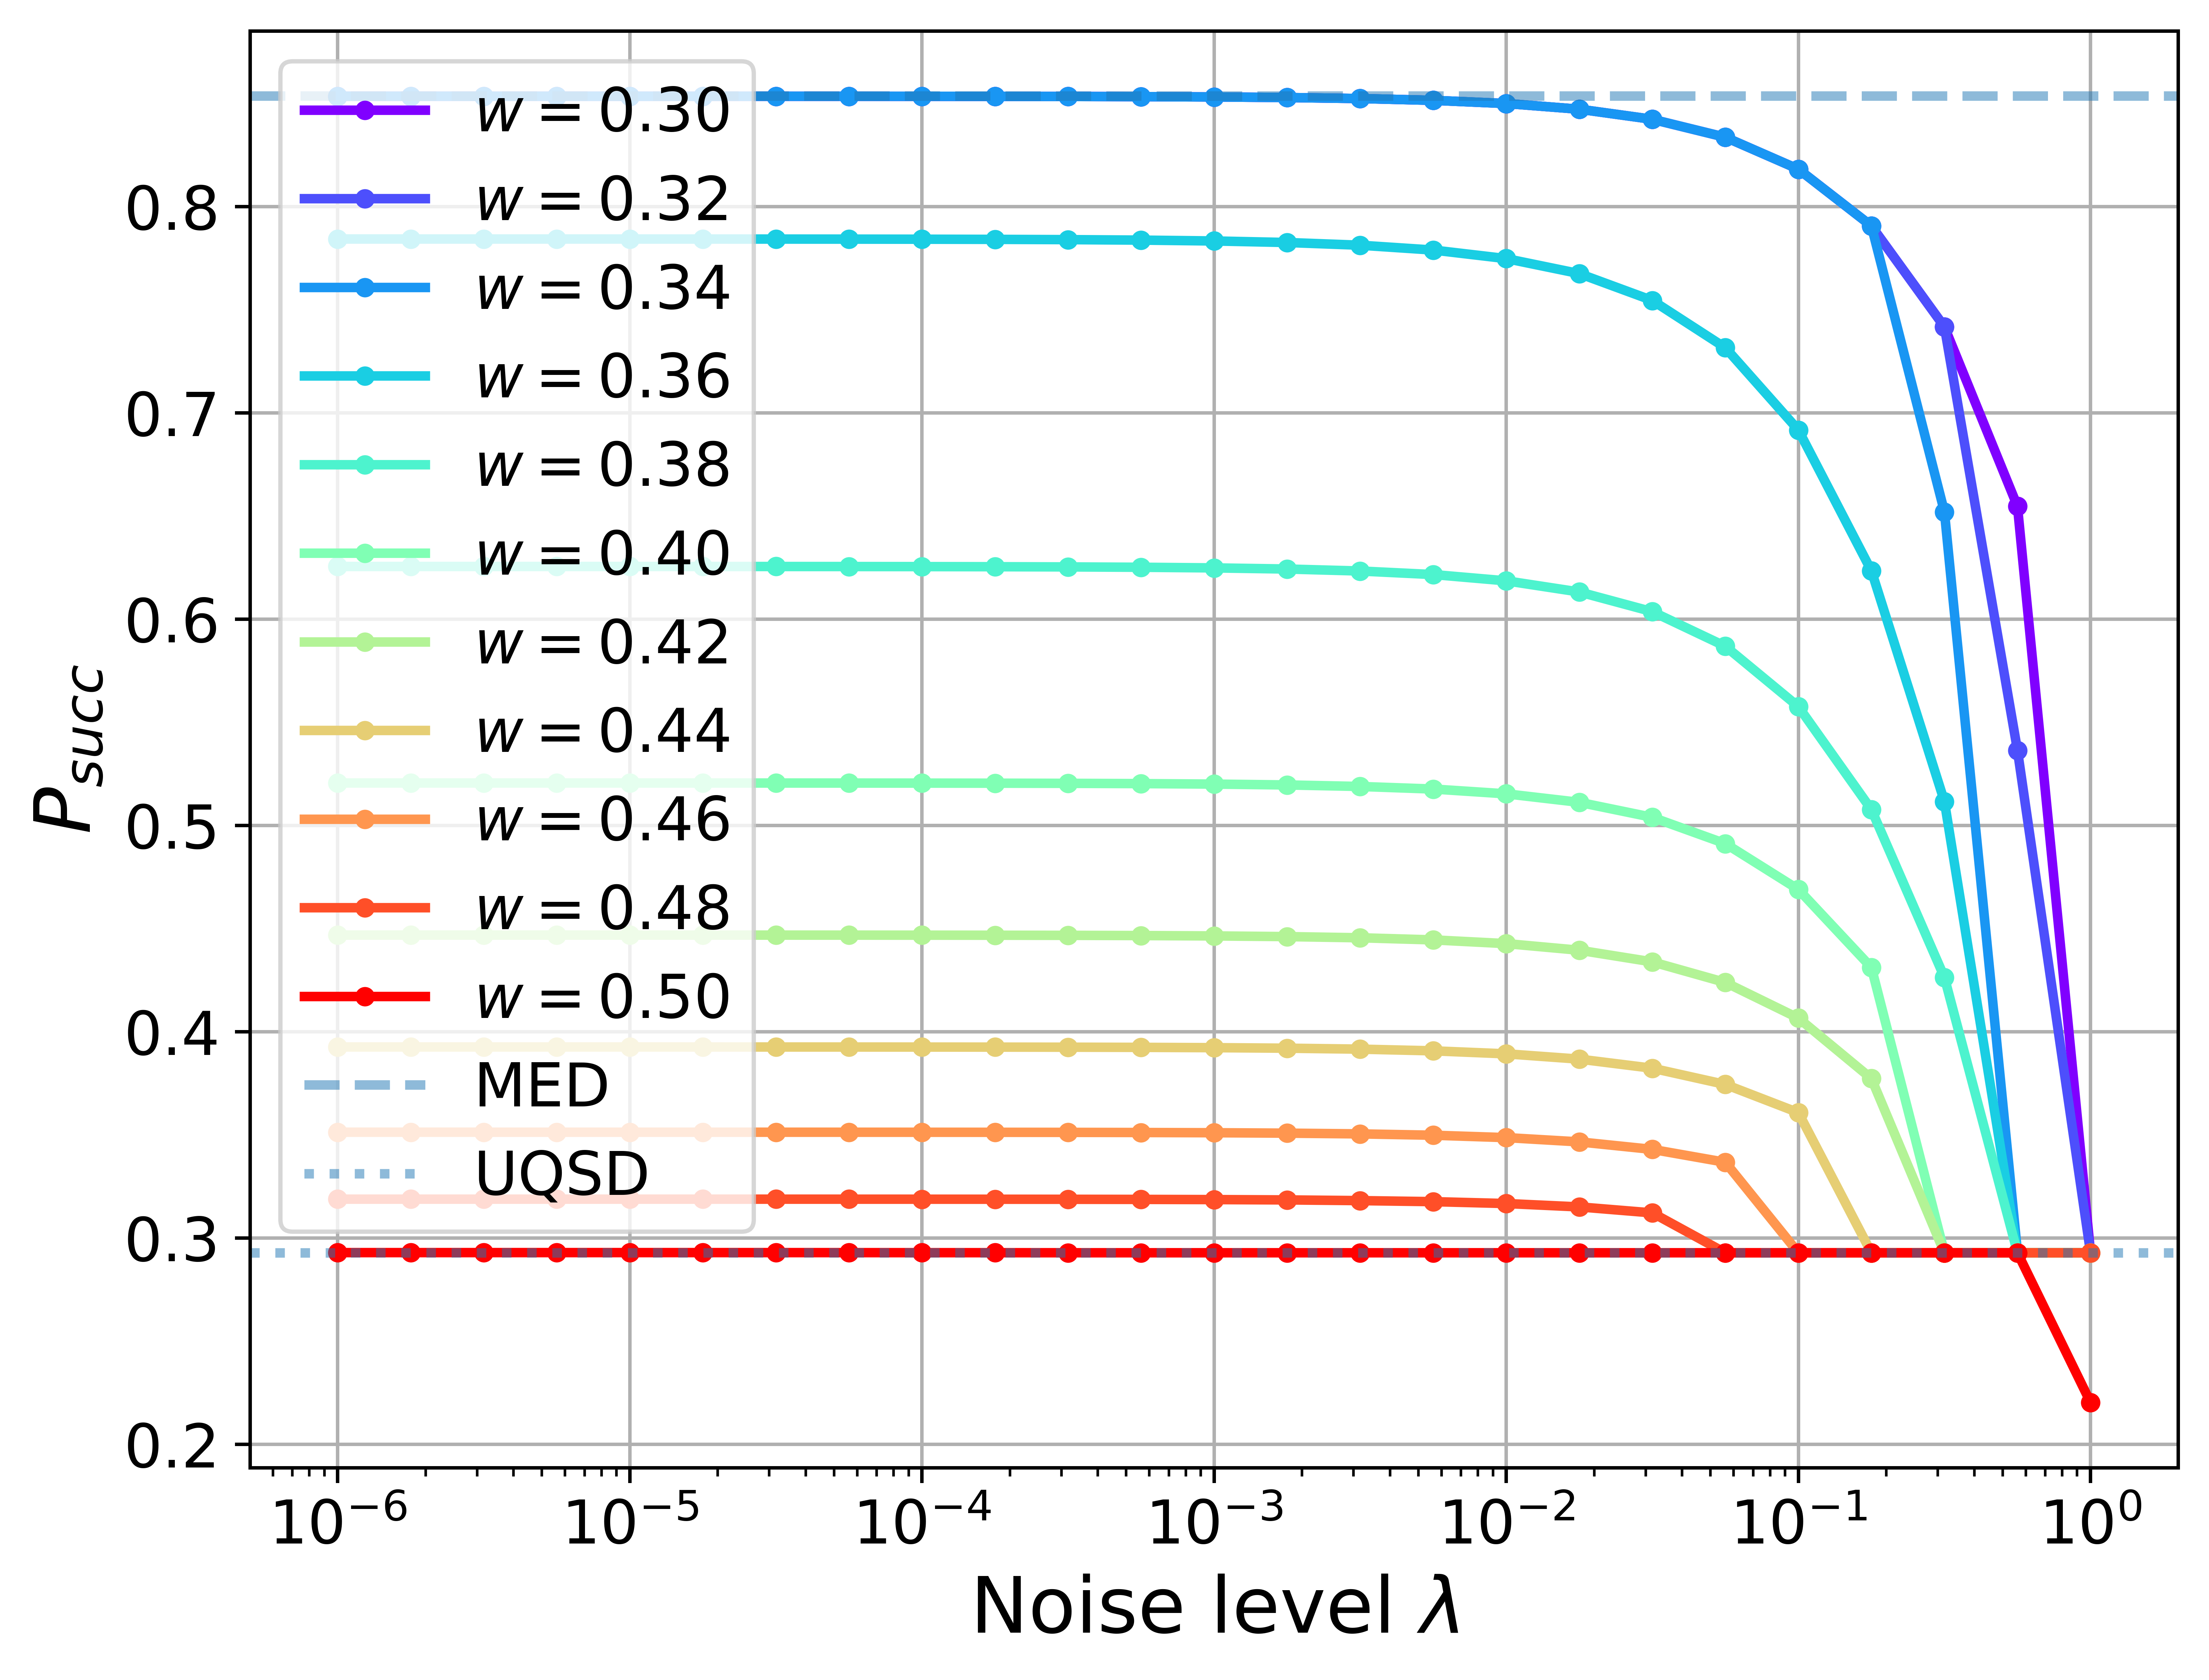

In [38]:
import matplotlib.pyplot as plt
from matplotlib import cm

plt.rcParams['image.cmap'] = 'rainbow'
rainbow = cm.get_cmap('rainbow', len(sqrtd_result_list))  # Get 5 colors from rainbow colormap
colors = [rainbow(i) for i in range(len(psucc_result_list))]

plt.figure(figsize=(8, 6), dpi=900)

for i, arr in enumerate(psucc_result_list):
    # if i >= 6:
    #     plt.plot(noise_levels, arr, ".-", label=rf'$1/w = {1/lamdah_list[i]:.1f}$')
    plt.plot(noise_levels, arr, ".-", color=colors[i], label=rf'$w = {lamdah_list[i]:.2f}$')

plt.axhline(med_opt_val, linestyle="--", label='MED', alpha=0.5)
plt.axhline(uqsd_opt_val, linestyle="dotted", label='UQSD', alpha=0.5)

plt.xlabel(r'Noise level $\lambda$')
plt.ylabel(r'$P_{succ}$')
plt.xscale('log')

# plt.title('3 almost-ortho 2-qubit states')
# plt.title('2 non-orthogonal 1-qubit states')
plt.legend(loc="upper left")
plt.grid(True)
plt.savefig("figures/2_nonortho_psucc.pdf", bbox_inches="tight")
plt.show()

In [39]:
# for psucc_results in psucc_result_list:
#     print(psucc_results[-1])

In [40]:
print(uqsd_opt_val)

0.2928932185164271


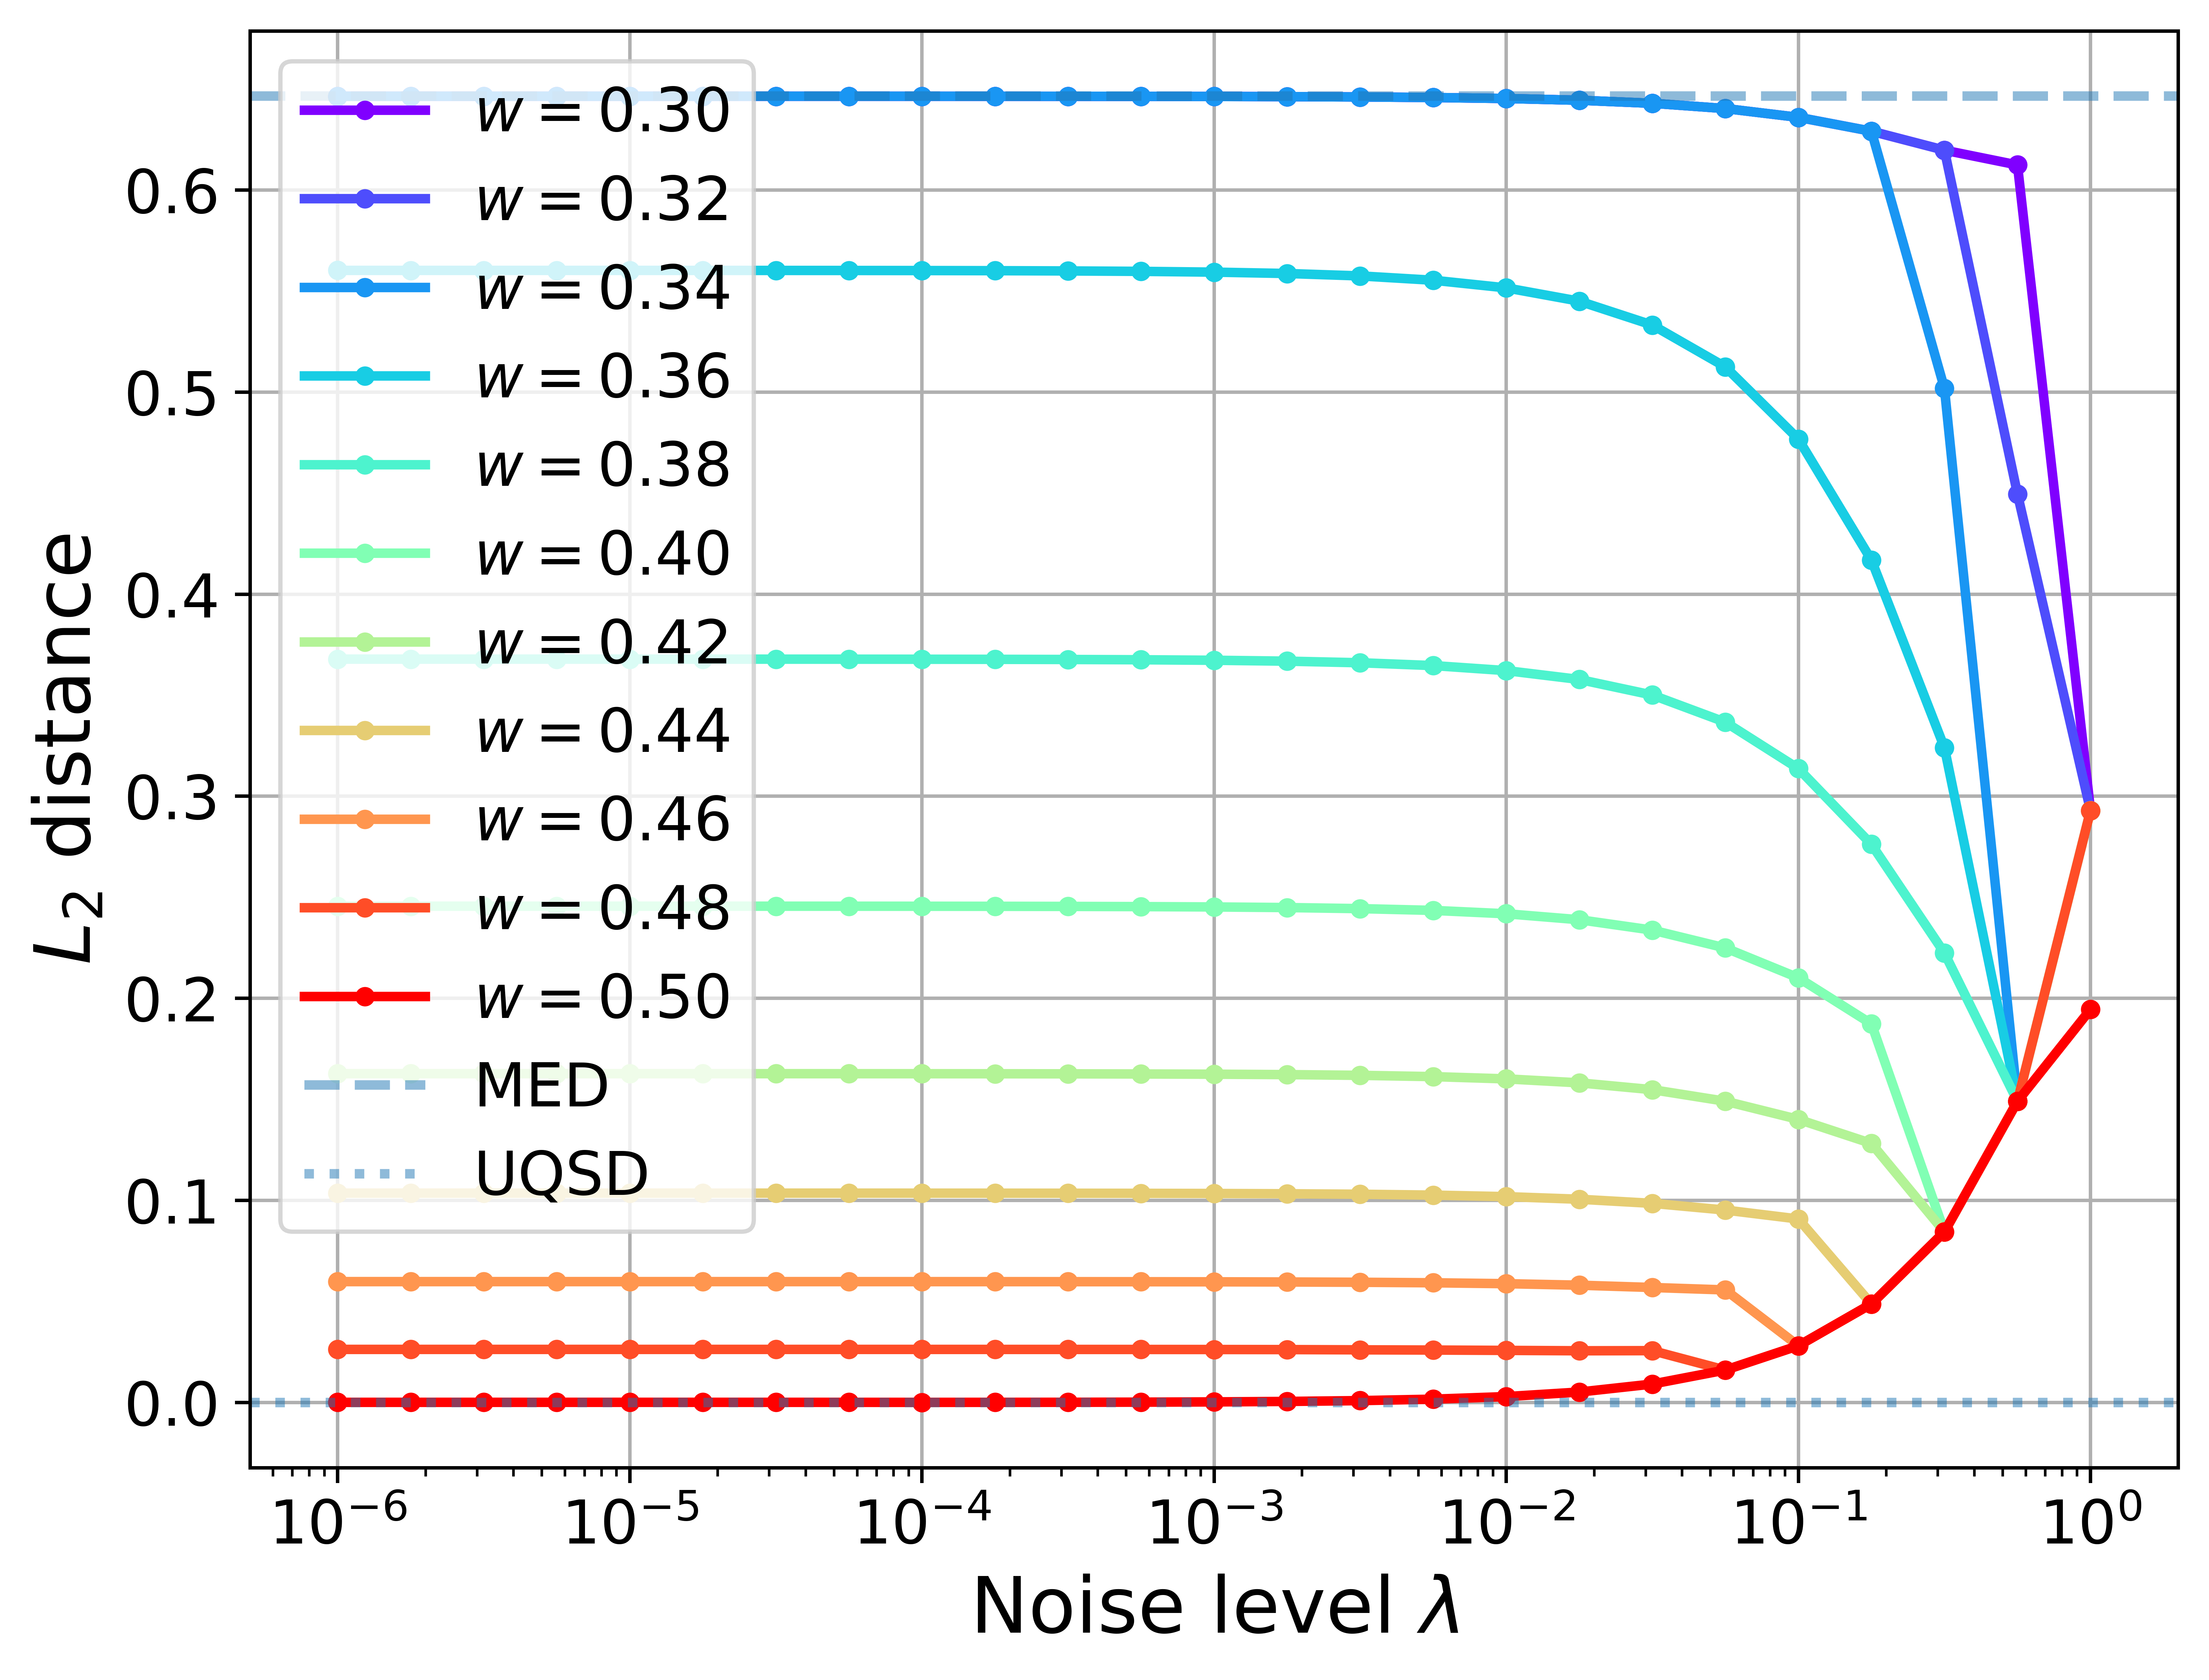

In [41]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

rainbow = colormaps['rainbow']
# rainbow = cm.get_cmap('rainbow', len(sqrtd_result_list))  # Get 5 colors from rainbow colormap
colors = [rainbow(i / (len(sqrtd_result_list) - 1)) for i in range(len(sqrtd_result_list))]

plt.figure(figsize=(8, 6), dpi=900)

for i, arr in enumerate(sqrtd_result_list):
    # if i >= 6:
    #     plt.plot(noise_levels, arr, ".-", label=rf'$w = {lamdah_list[i]:.2f}$')
    plt.plot(noise_levels, arr, ".-", color=colors[i], label=rf'$w = {lamdah_list[i]:.2f}$')

plt.axhline(med_l2, linestyle="--", label='MED', alpha=0.5)
plt.axhline(0, linestyle="dotted", label='UQSD', alpha=0.5)

plt.xlabel(r'Noise level $\lambda$')
plt.ylabel(r'$L_2$ distance')
plt.xscale('log')

# plt.title('3 almost-ortho 2-qubit states')
# plt.title('2 non-orthogonal 1-qubit states')
plt.legend(loc="upper left")
plt.grid(True)
plt.savefig("figures/2_nonortho_sqrtd.pdf", bbox_inches="tight")
plt.show()

In [42]:
"""
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=900)

for i, arr in enumerate(psucc_result_list):
    if (i + 1) % 2:
        plt.plot(noise_levels, arr, ".-", label=rf'$a_{1} = 0.001, a_{2} = {lamdah_list[i]:.2f}$')

plt.axhline(0.855, linestyle="--", label=rf'MED', alpha=0.5)
plt.axhline(0.292, linestyle="dotted", label='UQSD', alpha=0.5)

plt.xlabel(r'Noise level $\lambda$')
plt.ylabel(r'$P_{succ}$')
plt.xscale('log')
# plt.title('Two 1-qubit states 45deg')
plt.legend()
plt.grid(True)
plt.show()
"""

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3712620/2700539962.py:13: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(r'Noise level $\lambda$')


'\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(8, 6), dpi=900)\n\nfor i, arr in enumerate(psucc_result_list):\n    if (i + 1) % 2:\n        plt.plot(noise_levels, arr, ".-", label=rf\'$a_{1} = 0.001, a_{2} = {lamdah_list[i]:.2f}$\')\n\nplt.axhline(0.855, linestyle="--", label=rf\'MED\', alpha=0.5)\nplt.axhline(0.292, linestyle="dotted", label=\'UQSD\', alpha=0.5)\n\nplt.xlabel(r\'Noise level $\\lambda$\')\nplt.ylabel(r\'$P_{succ}$\')\nplt.xscale(\'log\')\n# plt.title(\'Two 1-qubit states 45deg\')\nplt.legend()\nplt.grid(True)\nplt.show()\n'

In [43]:
state_vec

[Statevector([1.+0.j, 0.+0.j],
             dims=(2,)),
 Statevector([0.7071+0.j, 0.7071+0.j],
             dims=(2,))]

In [44]:
import pandas as pd

# Assuming psucc_result_list, noise_levels, and lamdah_list are defined
# Create a DataFrame with noise_levels as index and each array in psucc_result_list as a column
df = pd.DataFrame(
    {f'a_2={lamdah_list[i]:.2f}': arr for i, arr in enumerate(psucc_result_list)},
    index=noise_levels
)

# Save to CSV
df.to_csv('psucc_results_3states.csv', index_label='noise_level')

In [45]:
jsd_result = []
sqrtd_result = []
psucc_result = []
eps_list = [1e-8]
# lamdah_list = [0.0001, 0.001, 0.01, 0.1, 1]
# lamdah_list = [1, 10, 100, 1000, 10000, 100000]
# lamdah_list = [0, 1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# lamdah_list = [0.1 * _ for _ in range(1, 10)]
lamdah_list = [0.3 + 0.02 * _ for _ in range(11)]
noise_levels = [0.1 ** (6 - 0.5 * i) for i in range(11)]
noise_levels = [0.1 ** (6 - 0.25 * i) for i in range(25)]
psucc_result_list = []
sqrtd_result_list = []
param_rh = [0.0001 for i in range(num_states)]
param_rv = [0.0001 for i in range(num_states + 1)]
param_rh = [0.001 for i in range(num_states)]
param_rv = [0.001 for i in range(num_states + 1)]

for param_a in lamdah_list:
    for eps in eps_list:
        jsd_result = []
        sqrtd_result = []
        psucc_result = []
        for noise_level in noise_levels:
            combined_states = [
                (1 - noise_level) * dense_mat[_]
                + noise_level * disturbance_states[_].data
                for _ in range(num_states)
            ]

            qsd_problem.set_states(
                state_type="densitymatrix",
                states=combined_states,
                overwrite=True,
            )

            # cvxpy_problem = balance_obj_2_problem(
            #     problem_spec=qsd_problem,
            #     ideal_distrib=ideal_distrib,
            #     param_b=param_b,
            #     param_rh=param_rh,
            #     param_rv=param_rv,
            # )
            cvxpy_problem = balance_obj_problem(
                problem_spec=qsd_problem,
                ideal_distrib=ideal_distrib,
                param_a=param_a,
            )

            run_qsd(
                qsd_problem=qsd_problem,
                cvxpy_problem=cvxpy_problem,
                jsd_result=jsd_result,
                sqrtd_result=sqrtd_result,
                psucc_result=psucc_result,
            )
        psucc_result_list.append(psucc_result)
        sqrtd_result_list.append(sqrtd_result)

/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18617: UserWarning: Argument sub in putvarboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putvarboundlist: Incorrect array format causing data to be copied");
/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18925: UserWarning: Argument subj in putclist: Incorrect array format causing data to be copied
  warnings.warn("Argument subj in putclist: Incorrect array format causing data to be copied");
/home/ChienKaiMa/QSD/.venv/lib/python3.12/site-packages/mosek/__init__.py:18349: UserWarning: Argument sub in putconboundlist: Incorrect array format causing data to be copied
  warnings.warn("Argument sub in putconboundlist: Incorrect array format causing data to be copied");


/tmp/ipykernel_3712620/2717384353.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rainbow = cm.get_cmap('rainbow', len(sqrtd_result_list))  # Get 5 colors from rainbow colormap


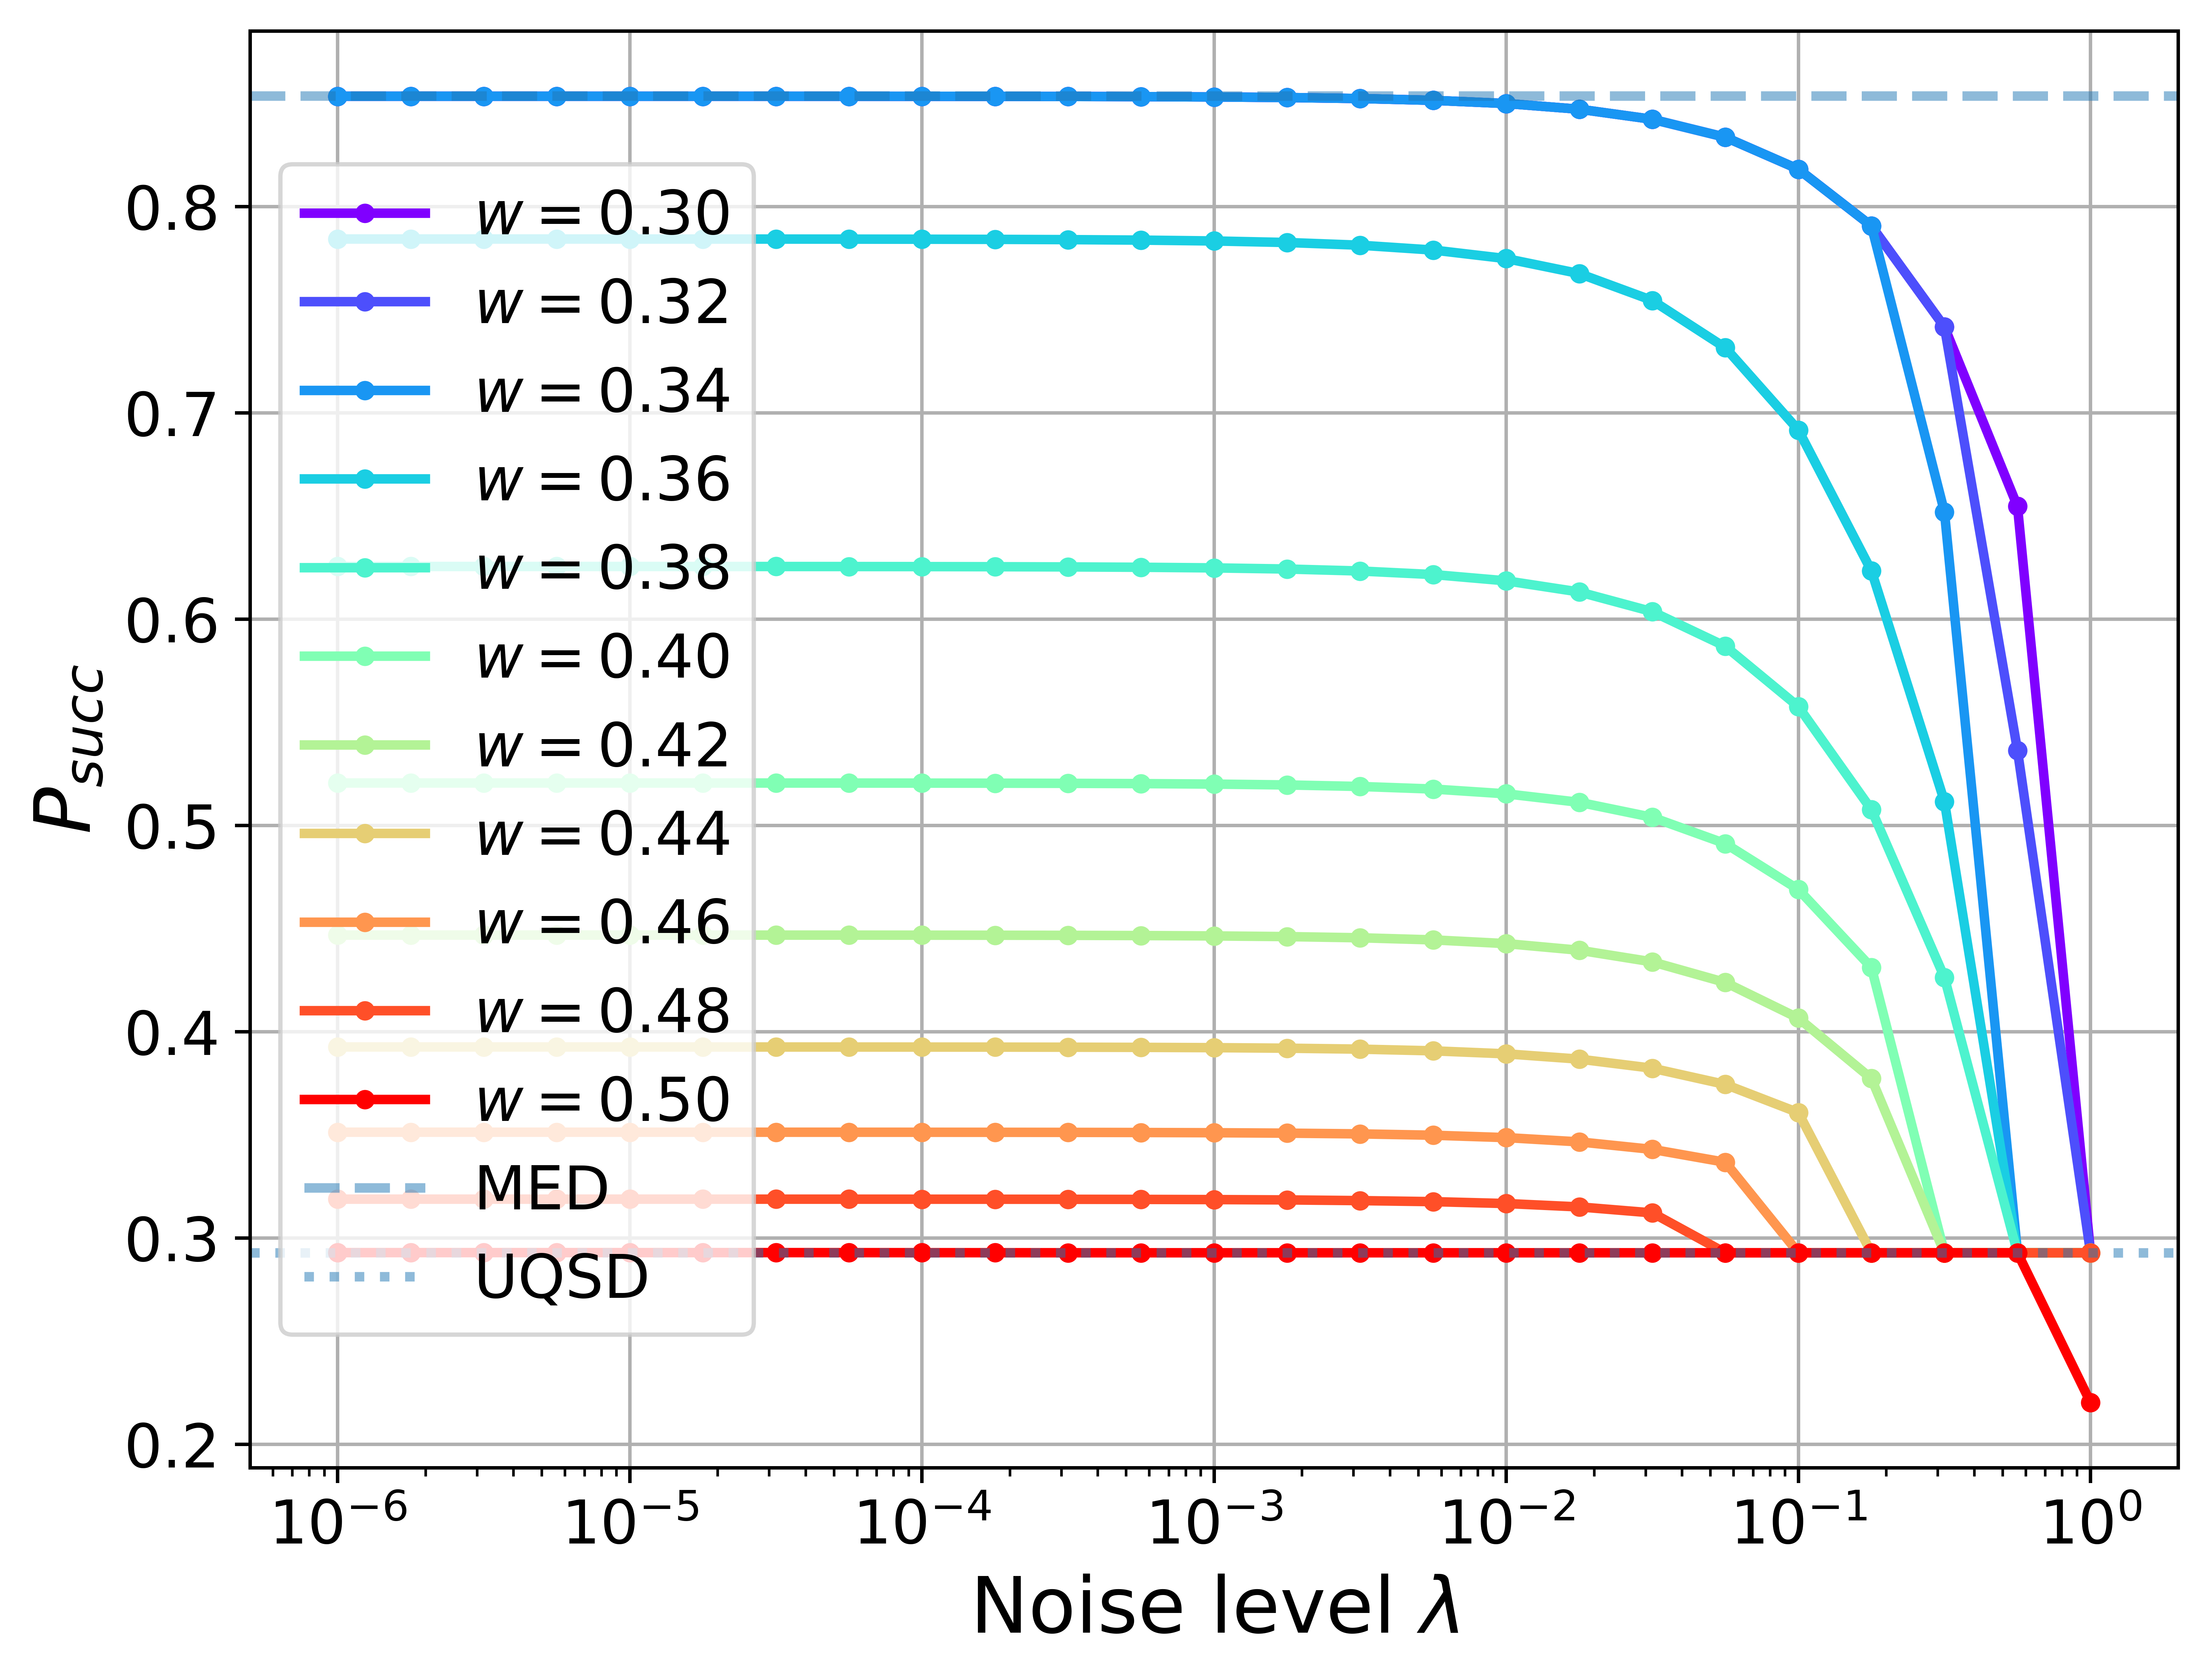

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=900)
plt.rcParams['image.cmap'] = 'rainbow'
rainbow = cm.get_cmap('rainbow', len(sqrtd_result_list))  # Get 5 colors from rainbow colormap
colors = [rainbow(i) for i in range(len(psucc_result_list))]

for i, arr in enumerate(psucc_result_list):
    # if i >= 6:
        # plt.plot(noise_levels, arr, ".-", label=rf'$1/w = {1/lamdah_list[i]:.1f}$')
    plt.plot(noise_levels, arr, ".-", color=colors[i], label=rf'$w = {lamdah_list[i]:.2f}$')

plt.axhline(med_opt_val, linestyle="--", label='MED', alpha=0.5)
plt.axhline(uqsd_opt_val, linestyle="dotted", label='UQSD', alpha=0.5)

plt.xlabel(r'Noise level $\lambda$')
plt.ylabel(r'$P_{succ}$')
plt.xscale('log')
# plt.ylim(0.7, 1)

# plt.title('3 2-qubit entangled states')
# plt.title('2 1-qubit states 45deg')
plt.legend(loc="center left")
plt.grid(True)
plt.savefig("figures/3_entangled_psucc.pdf", bbox_inches="tight")
plt.show()

In [47]:
print(psucc_result_list)

[[np.float64(0.853553034032011), np.float64(0.8535527588687228), np.float64(0.8535522695515412), np.float64(0.8535513994088155), np.float64(0.8535498520520025), np.float64(0.8535471004192017), np.float64(0.8535422072472321), np.float64(0.8535335058202831), np.float64(0.8535180322518947), np.float64(0.8534905159238675), np.float64(0.8534415842042803), np.float64(0.85335456993489), np.float64(0.8531998342513696), np.float64(0.8529246709718465), np.float64(0.852435353778823), np.float64(0.8515652110271363), np.float64(0.8500178539952157), np.float64(0.847266220831751), np.float64(0.8423730482012474), np.float64(0.8336716199677382), np.float64(0.8181980489674074), np.float64(0.7906817137921729), np.float64(0.7417499759325842), np.float64(0.6547356538841822), np.float64(0.29289321851338956)], [np.float64(0.8535530129185191), np.float64(0.8535527377547549), np.float64(0.853552248436706), np.float64(0.8535513782924928), np.float64(0.8535498309329625), np.float64(0.8535470792953369), np.float6

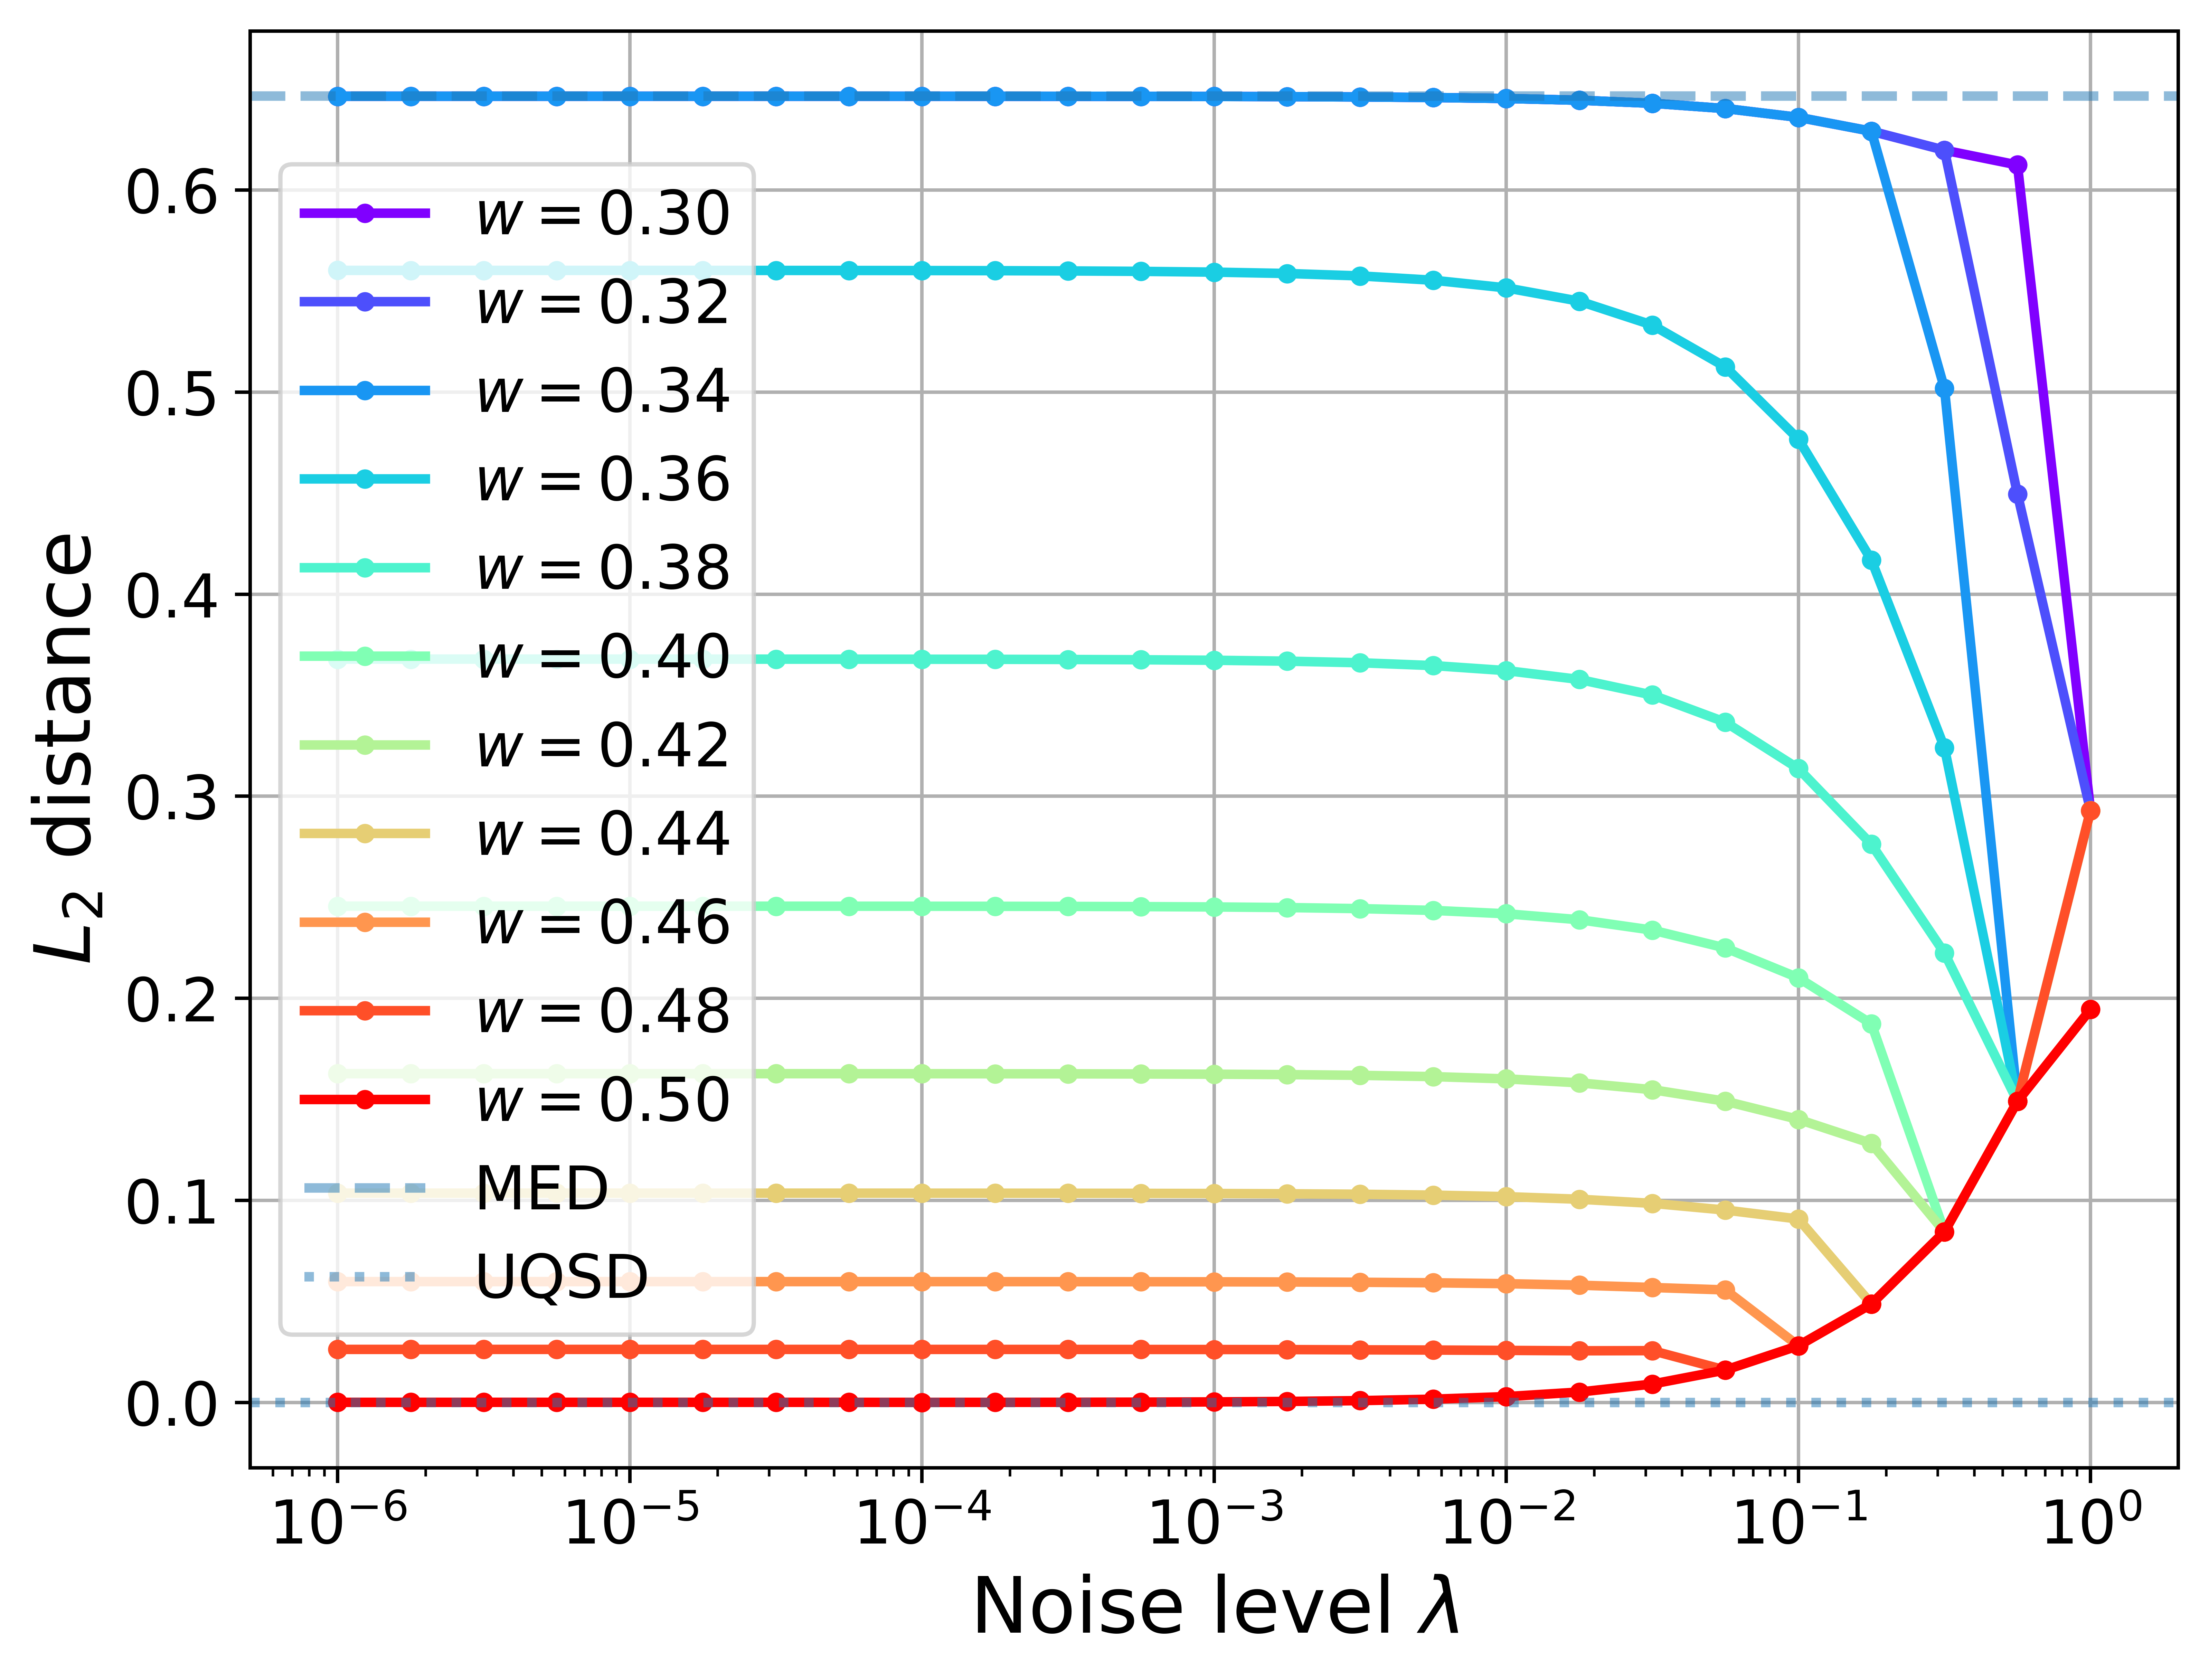

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=900)

for i, arr in enumerate(sqrtd_result_list):
    # if i >= 6:
    plt.plot(noise_levels, arr, ".-", color=colors[i], label=rf'$w = {lamdah_list[i]:.2f}$')
    # plt.plot(noise_levels, arr, ".-", label=rf'$1/w = {1/lamdah_list[i]:.1f}$')

plt.axhline(med_l2, linestyle="--", label='MED', alpha=0.5)
plt.axhline(0, linestyle="dotted", label='UQSD', alpha=0.5)

plt.xlabel(r'Noise level $\lambda$')
plt.ylabel(r'$L_2$ distance')
plt.xscale('log')

# plt.title('3 2-qubit entangled states')
# plt.title('2 1-qubit states 45deg')
# plt.ylim(-0.025, 0.15)
plt.legend(loc="center left")
plt.grid(True)
plt.savefig("figures/3_entangled_sqrtd.pdf", bbox_inches="tight")
plt.show()

In [49]:
state_vec

[Statevector([1.+0.j, 0.+0.j],
             dims=(2,)),
 Statevector([0.7071+0.j, 0.7071+0.j],
             dims=(2,))]

In [50]:
'''
from flow.solve_mix import *
from utils.handy_states import *

# states = state_dict["states"]
states = [
    Statevector([1, 0]),
    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),
]
# get_Phi_tilde
tmp_arr = []
for s in states:
    tmp_arr.append(s)
Phi = np.transpose(tmp_arr)
print("Phi")
print(Phi)
Phi_tilde = np.matmul(Phi, np.linalg.inv(np.matmul(Phi.conj().T, Phi)))
Phi_tilde = Phi_tilde.round(15)  # Remove nearzero value
Phi_tilde = Phi_tilde.T
print("Phi_tilde")
print(Phi_tilde)
'''

'\nfrom flow.solve_mix import *\nfrom utils.handy_states import *\n\n# states = state_dict["states"]\nstates = [\n    Statevector([1, 0]),\n    Statevector([1/np.sqrt(2), 1/np.sqrt(2)]),\n]\n# get_Phi_tilde\ntmp_arr = []\nfor s in states:\n    tmp_arr.append(s)\nPhi = np.transpose(tmp_arr)\nprint("Phi")\nprint(Phi)\nPhi_tilde = np.matmul(Phi, np.linalg.inv(np.matmul(Phi.conj().T, Phi)))\nPhi_tilde = Phi_tilde.round(15)  # Remove nearzero value\nPhi_tilde = Phi_tilde.T\nprint("Phi_tilde")\nprint(Phi_tilde)\n'

In [51]:
'''
for i in range(2):
    print(np.multiply(Phi_tilde[i][None].T.conj(), Phi_tilde[i]))
'''

'\nfor i in range(2):\n    print(np.multiply(Phi_tilde[i][None].T.conj(), Phi_tilde[i]))\n'

In [52]:
'''
problem_spec = ProblemSpec(num_qubits=num_qubits, num_states=num_states)
problem_spec.set_states(
    state_type="statevector",
    states=states,
    overwrite=True,
)
result = apply_Eldar(problem_spec=problem_spec)
result["sol"]
'''

'\nproblem_spec = ProblemSpec(num_qubits=num_qubits, num_states=num_states)\nproblem_spec.set_states(\n    state_type="statevector",\n    states=states,\n    overwrite=True,\n)\nresult = apply_Eldar(problem_spec=problem_spec)\nresult["sol"]\n'

In [53]:
'''
states = states[:2]
problem_spec = ProblemSpec(num_qubits=2, num_states=2)
problem_spec.set_states(
    state_type="statevector",
    states=states,
    overwrite=True,
)
result = apply_Eldar(problem_spec=problem_spec)

result["sol"]
'''

'\nstates = states[:2]\nproblem_spec = ProblemSpec(num_qubits=2, num_states=2)\nproblem_spec.set_states(\n    state_type="statevector",\n    states=states,\n    overwrite=True,\n)\nresult = apply_Eldar(problem_spec=problem_spec)\n\nresult["sol"]\n'